# Sierpiński Gasket Using Binary Addresses

This notebook implements and analyses the Sierpiński gasket using
binary coordinate addresses and PyTorch tensor operations.

The project demonstrates tensor parallelism, visualisation,
performance comparison, and fractal-dimension analysis.

In [2]:
import torch
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Selected device:", device)

PyTorch version: 2.13.0
Selected device: mps


## Binary-address rule

The Sierpiński gasket can be revealed through the parity pattern of
Pascal's triangle. A cell at row `n` and position `k` is odd when:

\[
k \;\&\; (n-k) = 0
\]

Here, `&` denotes the bitwise AND operation. This test avoids computing
the potentially very large binomial coefficient directly.

In [3]:
# Number of rows in Pascal's triangle
size = 256

# Integer addresses created directly on the selected device
indices = torch.arange(
    size,
    dtype=torch.int32,
    device=device
)

# Rows have shape (256, 1); columns have shape (1, 256)
rows = indices[:, None]
columns = indices[None, :]

# Only positions inside Pascal's triangular region are valid
valid_region = columns <= rows

# A Pascal cell is odd when no binary 1-bits overlap
binary_test = torch.bitwise_and(
    columns,
    rows - columns
) == 0

gasket = valid_region & binary_test

print("Gasket shape:", gasket.shape)
print("Gasket data type:", gasket.dtype)
print("Gasket device:", gasket.device)
print("Number of active points:", gasket.sum().item())

Gasket shape: torch.Size([256, 256])
Gasket data type: torch.bool
Gasket device: mps:0
Number of active points: 6561


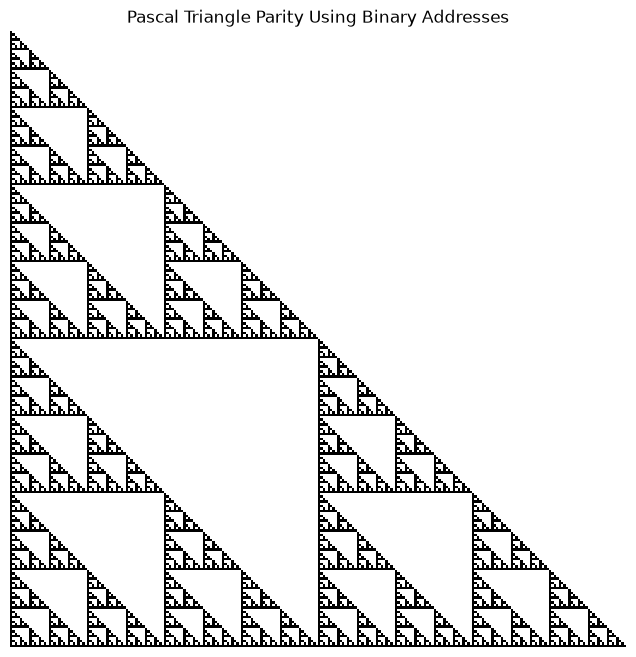

In [4]:
plt.figure(figsize=(8, 8))

plt.imshow(
    gasket.cpu().numpy(),
    cmap="binary",
    interpolation="nearest"
)

plt.title("Pascal Triangle Parity Using Binary Addresses")
plt.axis("off")
plt.show()

## Centred Sierpiński gasket

The binary-address calculation produces a left-aligned Pascal triangle.
For visualisation, each active cell at row `n` and position `k` is
mapped to the centred horizontal coordinate

\[
x = (N - 1 - n) + 2k
\]

This changes only the display coordinates. The membership of every
point is still determined by the binary-address test.

In [5]:
# Find the addresses of all active points
active_rows, active_columns = torch.where(gasket)

# Create a wider canvas for a centred triangle
centred_gasket = torch.zeros(
    (size, 2 * size - 1),
    dtype=torch.bool,
    device=device
)

# Convert Pascal addresses into centred display coordinates
centred_columns = (
    size - 1 - active_rows
    + 2 * active_columns
)

# Place the active points on the centred canvas
centred_gasket[
    active_rows,
    centred_columns
] = True

print("Centred image shape:", centred_gasket.shape)
print("Centred image device:", centred_gasket.device)
print("Number of active points:", centred_gasket.sum().item())

Centred image shape: torch.Size([256, 511])
Centred image device: mps:0
Number of active points: 6561


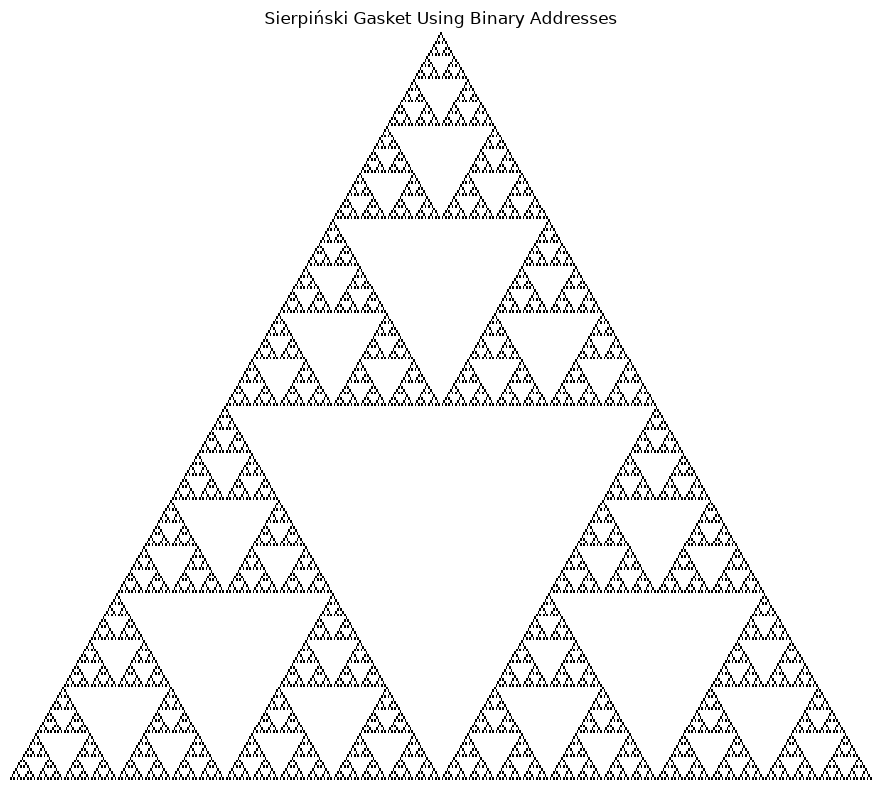

In [6]:
plt.figure(figsize=(10, 8))

plt.imshow(
    centred_gasket.cpu().numpy(),
    cmap="binary",
    interpolation="nearest",
    aspect=3 ** 0.5
)

plt.title("Sierpiński Gasket Using Binary Addresses")
plt.axis("off")
plt.tight_layout()
plt.show()

## Reusable PyTorch implementation

The generation process is placed inside a function so that different
image resolutions and computational devices can be tested consistently.
All pixel addresses are evaluated simultaneously using PyTorch tensor
operations, without a Python loop over individual pixels.

In [7]:
def generate_sierpinski(size, computation_device):
    """
    Generate raw and centred Sierpiński gasket masks using
    the binary-address test.

    Parameters
    ----------
    size : int
        Number of rows in Pascal's triangle.
    computation_device : torch.device
        Device used for tensor calculations.

    Returns
    -------
    raw_gasket : torch.Tensor
        Left-aligned Pascal parity mask.
    centred_gasket : torch.Tensor
        Centred visualisation mask.
    """
    if not isinstance(size, int) or size < 2:
        raise ValueError("size must be an integer greater than 1")

    indices = torch.arange(
        size,
        dtype=torch.int32,
        device=computation_device
    )

    rows = indices[:, None]
    columns = indices[None, :]

    valid_region = columns <= rows

    binary_test = torch.bitwise_and(
        columns,
        rows - columns
    ) == 0

    raw_gasket = valid_region & binary_test

    active_rows, active_columns = torch.where(raw_gasket)

    centred_gasket = torch.zeros(
        (size, 2 * size - 1),
        dtype=torch.bool,
        device=computation_device
    )

    centred_columns = (
        size - 1 - active_rows
        + 2 * active_columns
    )

    centred_gasket[
        active_rows,
        centred_columns
    ] = True

    return raw_gasket, centred_gasket

In [8]:
high_resolution_size = 1024

raw_high_res, centred_high_res = generate_sierpinski(
    high_resolution_size,
    device
)

print("Raw shape:", raw_high_res.shape)
print("Centred shape:", centred_high_res.shape)
print("Device:", centred_high_res.device)
print("Active points:", centred_high_res.sum().item())

Raw shape: torch.Size([1024, 1024])
Centred shape: torch.Size([1024, 2047])
Device: mps:0
Active points: 59049


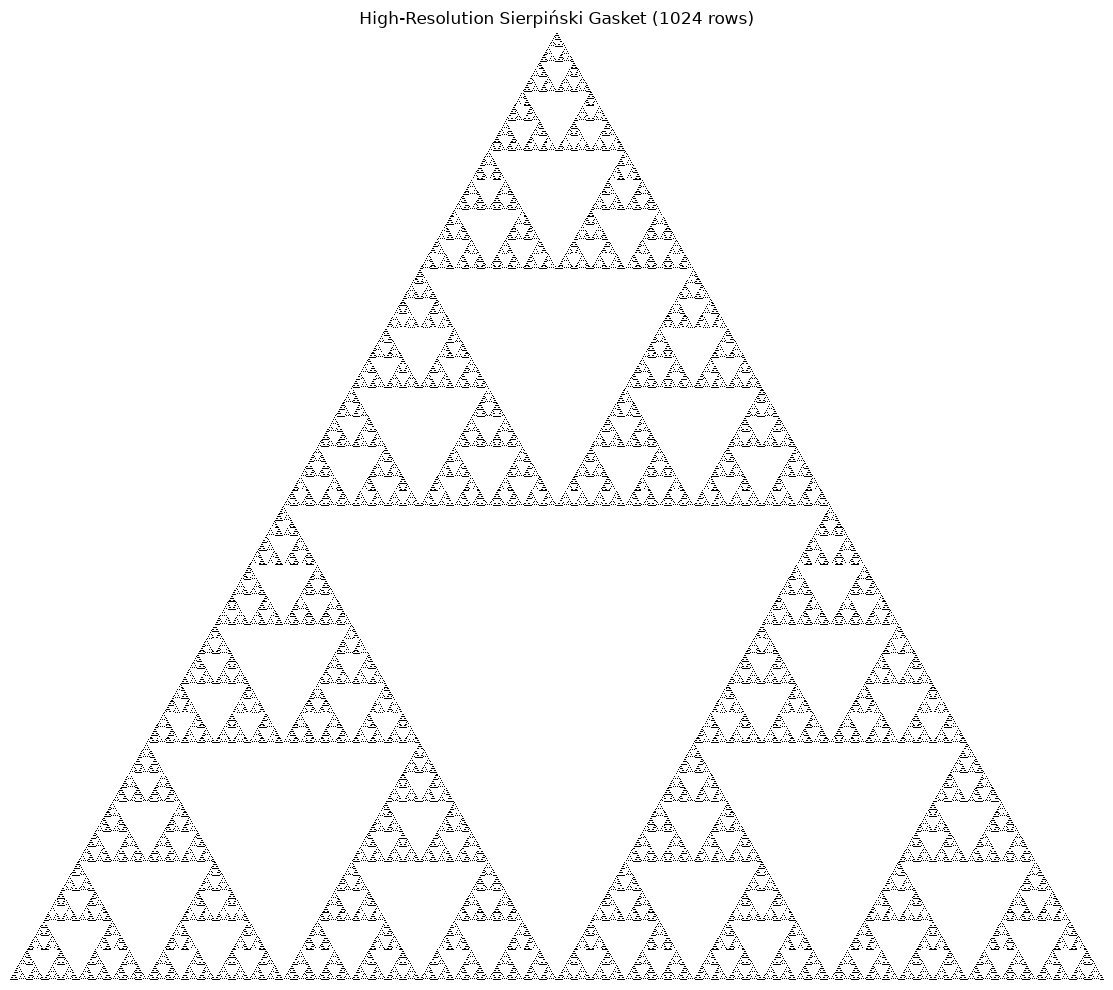

In [9]:
plt.figure(figsize=(12, 10))

plt.imshow(
    centred_high_res.cpu().numpy(),
    cmap="binary",
    interpolation="nearest",
    aspect=3 ** 0.5
)

plt.title(
    f"High-Resolution Sierpiński Gasket "
    f"({high_resolution_size} rows)"
)

plt.axis("off")
plt.tight_layout()
plt.show()

## Robust CPU and MPS performance comparison

The same vectorised PyTorch implementation is benchmarked on CPU and
Apple MPS across multiple image sizes.

For each size and device:

- three warm-up runs are performed;
- twenty measured runs are collected;
- MPS is synchronised before and after timing;
- the device testing order is randomised;
- the median is used as the representative time;
- the interquartile range shows timing variability.

The Sierpiński generation itself is deterministic. Any variation in
execution time is caused by factors such as device scheduling, memory
allocation, temperature, and background system activity.

In [16]:
import time
import random
import numpy as np


def synchronise_device(computation_device):
    """
    Wait until asynchronous operations on the selected device
    have completed.
    """
    if computation_device.type == "mps":
        torch.mps.synchronize()

    elif computation_device.type == "cuda":
        torch.cuda.synchronize()

In [17]:
def benchmark_distribution(
    size,
    computation_device,
    repeats=20,
    warmups=3
):
    """
    Benchmark Sierpiński generation repeatedly.

    Parameters
    ----------
    size : int
        Number of Pascal-triangle rows.

    computation_device : torch.device
        CPU, MPS, or CUDA device used for generation.

    repeats : int
        Number of measured runs.

    warmups : int
        Number of unmeasured warm-up runs.

    Returns
    -------
    numpy.ndarray
        Individual execution times in milliseconds.
    """

    # Warm-up runs reduce one-time initialisation effects
    for _ in range(warmups):
        warmup_raw, warmup_centred = generate_sierpinski(
            size,
            computation_device
        )

        synchronise_device(computation_device)

        del warmup_raw, warmup_centred

    elapsed_times = []

    # Collect repeated timing measurements
    for _ in range(repeats):
        synchronise_device(computation_device)

        start_time = time.perf_counter_ns()

        result_raw, result_centred = generate_sierpinski(
            size,
            computation_device
        )

        synchronise_device(computation_device)

        end_time = time.perf_counter_ns()

        elapsed_milliseconds = (
            end_time - start_time
        ) / 1_000_000

        elapsed_times.append(elapsed_milliseconds)

        del result_raw, result_centred

    return np.array(elapsed_times)

In [18]:
# More checkpoints give a clearer performance trend
benchmark_sizes = [
    256,
    384,
    512,
    768,
    1024,
    1536,
    2048,
    2560,
    3072,
    3584,
    4096
]

cpu_device = torch.device("cpu")
accelerator_device = device
accelerator_label = accelerator_device.type.upper()

repeats = 20
warmups = 3

# Store every individual timing measurement
timing_samples = {
    "CPU": {},
    accelerator_label: {}
}

# Reproducible randomisation of device testing order
random_generator = random.Random(3710)

print("Benchmark configuration")
print("-----------------------")
print("Sizes:", benchmark_sizes)
print("Measured runs per configuration:", repeats)
print("Warm-up runs per configuration:", warmups)
print("Accelerator:", accelerator_label)

Benchmark configuration
-----------------------
Sizes: [256, 384, 512, 768, 1024, 1536, 2048, 2560, 3072, 3584, 4096]
Measured runs per configuration: 20
Warm-up runs per configuration: 3
Accelerator: MPS


In [19]:
for benchmark_size in benchmark_sizes:

    devices_to_test = [
        ("CPU", cpu_device),
        (accelerator_label, accelerator_device)
    ]

    # Avoid always testing one device first
    random_generator.shuffle(devices_to_test)

    for label, test_device in devices_to_test:
        timing_samples[label][benchmark_size] = (
            benchmark_distribution(
                size=benchmark_size,
                computation_device=test_device,
                repeats=repeats,
                warmups=warmups
            )
        )

    cpu_samples = timing_samples["CPU"][benchmark_size]

    accelerator_samples = timing_samples[
        accelerator_label
    ][benchmark_size]

    cpu_median = np.median(cpu_samples)

    accelerator_median = np.median(
        accelerator_samples
    )

    print(
        f"Size {benchmark_size:4d}: "
        f"CPU median = {cpu_median:8.3f} ms, "
        f"{accelerator_label} median = "
        f"{accelerator_median:8.3f} ms"
    )

Size  256: CPU median =    0.245 ms, MPS median =    0.673 ms
Size  384: CPU median =    0.234 ms, MPS median =    0.746 ms
Size  512: CPU median =    0.354 ms, MPS median =    0.943 ms
Size  768: CPU median =    0.660 ms, MPS median =    1.423 ms
Size 1024: CPU median =    1.169 ms, MPS median =    2.539 ms
Size 1536: CPU median =    2.154 ms, MPS median =    3.973 ms
Size 2048: CPU median =    5.027 ms, MPS median =    5.630 ms
Size 2560: CPU median =    6.984 ms, MPS median =    7.204 ms
Size 3072: CPU median =    9.590 ms, MPS median =    9.636 ms
Size 3584: CPU median =   12.323 ms, MPS median =    9.903 ms
Size 4096: CPU median =   16.273 ms, MPS median =   12.778 ms


In [20]:
benchmark_summary = {}

for label in ["CPU", accelerator_label]:

    medians = []
    lower_quartiles = []
    upper_quartiles = []

    for benchmark_size in benchmark_sizes:

        samples = timing_samples[label][benchmark_size]

        medians.append(
            np.median(samples)
        )

        lower_quartiles.append(
            np.percentile(samples, 25)
        )

        upper_quartiles.append(
            np.percentile(samples, 75)
        )

    benchmark_summary[label] = {
        "median": np.array(medians),
        "q1": np.array(lower_quartiles),
        "q3": np.array(upper_quartiles)
    }


cpu_medians = benchmark_summary["CPU"]["median"]

accelerator_medians = benchmark_summary[
    accelerator_label
]["median"]

speedups = cpu_medians / accelerator_medians

print("Performance summary")
print("-------------------")

for index, benchmark_size in enumerate(benchmark_sizes):
    print(
        f"Size {benchmark_size:4d}: "
        f"CPU = {cpu_medians[index]:8.3f} ms, "
        f"{accelerator_label} = "
        f"{accelerator_medians[index]:8.3f} ms, "
        f"speedup = {speedups[index]:5.2f}x"
    )

Performance summary
-------------------
Size  256: CPU =    0.245 ms, MPS =    0.673 ms, speedup =  0.36x
Size  384: CPU =    0.234 ms, MPS =    0.746 ms, speedup =  0.31x
Size  512: CPU =    0.354 ms, MPS =    0.943 ms, speedup =  0.38x
Size  768: CPU =    0.660 ms, MPS =    1.423 ms, speedup =  0.46x
Size 1024: CPU =    1.169 ms, MPS =    2.539 ms, speedup =  0.46x
Size 1536: CPU =    2.154 ms, MPS =    3.973 ms, speedup =  0.54x
Size 2048: CPU =    5.027 ms, MPS =    5.630 ms, speedup =  0.89x
Size 2560: CPU =    6.984 ms, MPS =    7.204 ms, speedup =  0.97x
Size 3072: CPU =    9.590 ms, MPS =    9.636 ms, speedup =  1.00x
Size 3584: CPU =   12.323 ms, MPS =    9.903 ms, speedup =  1.24x
Size 4096: CPU =   16.273 ms, MPS =   12.778 ms, speedup =  1.27x


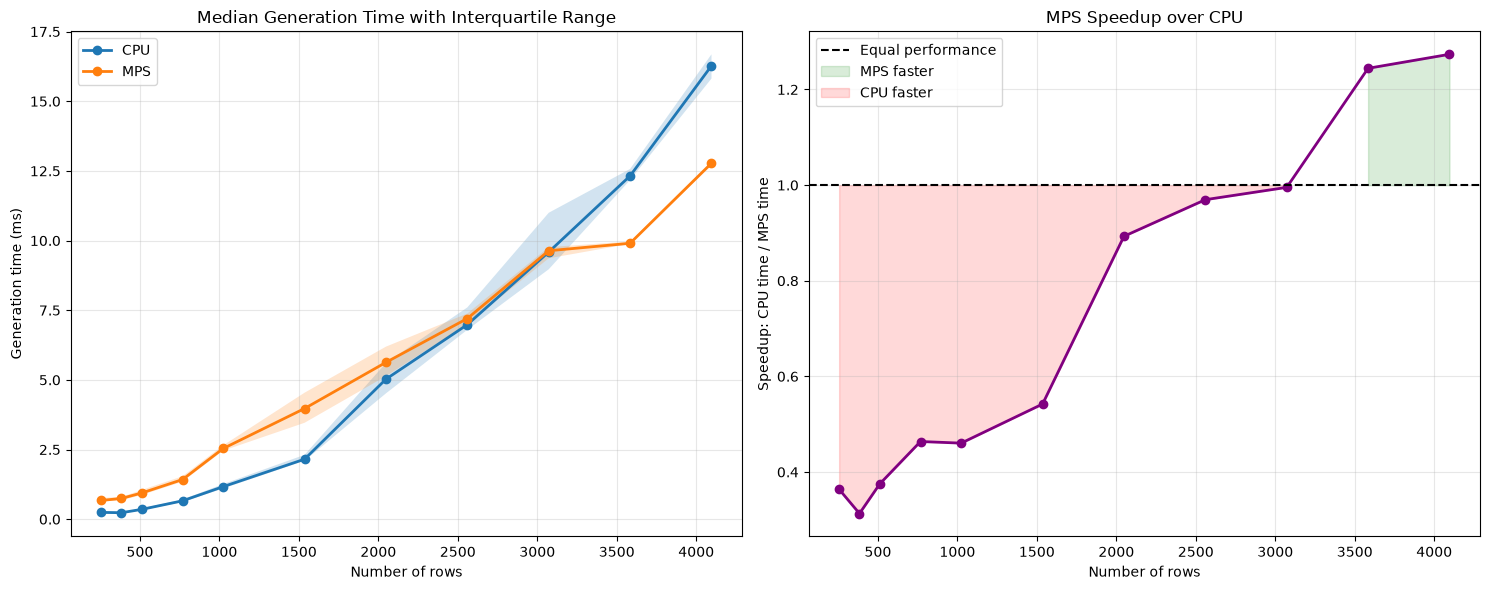

In [21]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

# Plot 1: execution time with interquartile ranges
for label in ["CPU", accelerator_label]:

    summary = benchmark_summary[label]

    axes[0].plot(
        benchmark_sizes,
        summary["median"],
        marker="o",
        linewidth=2,
        label=label
    )

    axes[0].fill_between(
        benchmark_sizes,
        summary["q1"],
        summary["q3"],
        alpha=0.2
    )

axes[0].set_xlabel("Number of rows")
axes[0].set_ylabel("Generation time (ms)")
axes[0].set_title(
    "Median Generation Time with Interquartile Range"
)
axes[0].grid(alpha=0.3)
axes[0].legend()


# Plot 2: accelerator speedup
axes[1].plot(
    benchmark_sizes,
    speedups,
    marker="o",
    color="purple",
    linewidth=2
)

axes[1].axhline(
    1.0,
    color="black",
    linestyle="--",
    label="Equal performance"
)

axes[1].fill_between(
    benchmark_sizes,
    speedups,
    1.0,
    where=(speedups >= 1.0),
    color="green",
    alpha=0.15,
    label=f"{accelerator_label} faster"
)

axes[1].fill_between(
    benchmark_sizes,
    speedups,
    1.0,
    where=(speedups < 1.0),
    color="red",
    alpha=0.15,
    label="CPU faster"
)

axes[1].set_xlabel("Number of rows")
axes[1].set_ylabel(
    f"Speedup: CPU time / {accelerator_label} time"
)
axes[1].set_title(
    f"{accelerator_label} Speedup over CPU"
)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Performance interpretation

The refined benchmark used 11 image sizes, 20 measured runs per
device and size, three warm-up runs, device synchronisation, and the
median as the representative execution time. The interquartile ranges
show that the overall trend is more important than small differences
between individual measurements.

For small and medium images, CPU execution is faster. The binary
operations are relatively lightweight, so the overhead of scheduling
the calculation on MPS is larger than the benefit of accelerator
parallelism.

At 3072 rows, CPU and MPS have approximately equal performance. MPS
becomes clearly faster at 3584 rows, where the measured speedup is
approximately 1.24 times.

At the largest tested resolution of 4096 rows:

- CPU median time: 16.273 ms
- MPS median time: 12.778 ms
- MPS speedup: approximately 1.27 times
- execution-time reduction: approximately 21.5%

These results demonstrate that PyTorch accelerator parallelism becomes
beneficial once the coordinate grid is sufficiently large. They also
show that using an accelerator does not automatically improve small
workloads because device scheduling and memory-management overheads
must first be overcome.